# Binary Classification with a Small-CNN Ensemble

An ensemble of two small from-scratch CNNs on PneumoniaMNIST, with test-time augmentation,
probability calibration, balanced and clinical operating points, and a Grad-CAM heatmap.
This mirrors the full-resolution chest
[07](../chest-x-ray-images-pneumonia/07_ensemble.ipynb), scaled down to 28x28. Averaging two
diverse CNNs smooths out each one's idiosyncratic mistakes, and calibration plus an explicit
operating point make the probabilities and the confusion matrix honest.

## Setup

In [1]:
# One-time setup: make the `visualization` helper importable, then fetch data +
# resolve paths. Each study's fetch logic lives in its own download_data.py.
import os
import sys

if "google.colab" in sys.modules:
    if not os.path.isdir("ConvolutedComputerVision"):
        !git clone -q https://github.com/samlowe106/ConvolutedComputerVision.git
    sys.path.insert(0, "ConvolutedComputerVision/src")

from visualization import colab_bootstrap

DATA_ROOT, CKPT_ROOT = colab_bootstrap(study="pneumonia_mnist")

Mounted at /content/drive
[colab_bootstrap] Colab run -> data='/content/drive/MyDrive/datasets/pneumonia-mnist', ckpt='/content/drive/MyDrive/cv-checkpoints'
[colab_bootstrap] WARNING: no GPU visible -- training will be very slow. Set Runtime > Change runtime type > GPU, then Runtime > Restart.


In [2]:
import datetime

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from scipy.optimize import minimize_scalar
from sklearn.calibration import calibration_curve
from sklearn.metrics import precision_recall_curve, roc_auc_score, roc_curve

notebook_start_time = datetime.datetime.now()

In [3]:
# load the MedMNIST PneumoniaMNIST .npz (fetched by download_data.py via the
# colab_bootstrap cell). Each split is (N, 28, 28) uint8 images + {0: normal, 1: pneumonia}.
_npz = np.load(os.path.join(DATA_ROOT, "pneumoniamnist.npz"))


def _make_ds(split):
    images = _npz[f"{split}_images"][..., None]  # add channel -> (N, 28, 28, 1)
    labels = _npz[f"{split}_labels"].reshape(-1).astype("int32")
    return tf.data.Dataset.from_tensor_slices((images, labels))


batch_size = 32
train_ds = _make_ds("train").batch(batch_size).prefetch(tf.data.AUTOTUNE)
validation_ds = _make_ds("val").batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_ds = _make_ds("test").batch(batch_size).prefetch(tf.data.AUTOTUNE)

y_val = np.concatenate([y for _, y in validation_ds], axis=0)
y_test = np.concatenate([y for _, y in test_ds], axis=0)

In [4]:
from visualization import (
    class_weights,
    reset_keras,
    show_confusion_matrix,
    show_gradcam,
    summary_graphics,
)

class_weight = class_weights(train_ds, cache_dir=DATA_ROOT)
print(f"Weight for normal class: {class_weight[0]:1.3f}")
print(f"Weight for pneumonia class: {class_weight[1]:1.3f}")

Weight for normal class: 1.000
Weight for pneumonia class: 0.347


## The ensemble members

We train two different small CNNs so their errors are at least partly uncorrelated, which is
the point of an ensemble. `cnn_a` is wider with separable convolutions; `cnn_b` is deeper
with more pooling. Both keep their last convolution at a resolution where Grad-CAM still
means something, use light augmentation (no horizontal flip, since chest anatomy is
left/right specific), and rescale inside the model.

In [5]:
metrics = [
    tf.keras.metrics.TruePositives(name="tp"),
    tf.keras.metrics.TrueNegatives(name="tn"),
    tf.keras.metrics.BinaryAccuracy(name="accuracy"),
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall"),
    tf.keras.metrics.AUC(name="auc"),
]


def make_callbacks(filepath):
    # select on val AUC (threshold-free, robust to the 74/26 class imbalance)
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=filepath, save_best_only=True, monitor="val_auc", mode="max"
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_auc", mode="max", patience=6, restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", mode="min", factor=0.5, patience=3
        ),
    ]


epochs = 25

In [6]:
def build_cnn_a():
    return tf.keras.models.Sequential(
        [
            tf.keras.layers.Input((28, 28, 1), name="input"),
            tf.keras.layers.RandomRotation(0.1),
            tf.keras.layers.RandomZoom(0.1),
            tf.keras.layers.Rescaling(1.0 / 255),
            tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
            tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
            tf.keras.layers.MaxPooling2D(),
            tf.keras.layers.SeparableConv2D(64, 3, padding="same", activation="relu"),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.SeparableConv2D(64, 3, padding="same", activation="relu"),
            tf.keras.layers.GlobalAveragePooling2D(),
            tf.keras.layers.Dropout(0.3),
            tf.keras.layers.Dense(64, activation="relu"),
            tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
        ],
        name="cnn_a",
    )


def build_cnn_b():
    # a deeper, narrower variant with more pooling, for ensemble diversity
    return tf.keras.models.Sequential(
        [
            tf.keras.layers.Input((28, 28, 1), name="input"),
            tf.keras.layers.RandomRotation(0.1),
            tf.keras.layers.RandomTranslation(0.1, 0.1),
            tf.keras.layers.Rescaling(1.0 / 255),
            tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu"),
            tf.keras.layers.MaxPooling2D(),
            tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
            tf.keras.layers.MaxPooling2D(),
            tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
            tf.keras.layers.GlobalAveragePooling2D(),
            tf.keras.layers.Dropout(0.3),
            tf.keras.layers.Dense(64, activation="relu"),
            tf.keras.layers.Dense(1, activation="sigmoid", name="output"),
        ],
        name="cnn_b",
    )


# (label, builder). Comment a line out to drop a member.
MEMBERS = [("cnn_a", build_cnn_a), ("cnn_b", build_cnn_b)]

In [7]:
def train_member(label, builder):
    # from-scratch training (no pretrained backbone to freeze), then keep the best epoch
    reset_keras()
    print(f"\n========== training member: {label} ==========")
    model = builder()
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=metrics,
    )
    ckpt_path = os.path.join(CKPT_ROOT, f"best_{label}.keras")
    history = model.fit(
        train_ds,
        validation_data=validation_ds,
        epochs=epochs,
        class_weight=class_weight,
        verbose=1,
        callbacks=make_callbacks(ckpt_path),
    )
    best = tf.keras.models.load_model(ckpt_path)
    summary_graphics(history, best, test_ds)
    return ckpt_path

## Train each member


========== training member: cnn_a ==========
Epoch 1/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 39s 178ms/step - accuracy: 0.8090 - auc: 0.8638 - loss: 0.2411 - precision: 0.8933 - recall: 0.8434 - tn: 862.0000 - tp: 2947.0000 - val_accuracy: 0.7519 - val_auc: 0.9034 - val_loss: 0.5701 - val_precision: 0.9675 - val_recall: 0.6889 - val_tn: 126.0000 - val_tp: 268.0000 - learning_rate: 0.0010
Epoch 2/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 29s 102ms/step - accuracy: 0.8696 - auc: 0.9446 - loss: 0.1537 - precision: 0.9604 - recall: 0.8598 - tn: 1090.0000 - tp: 3004.0000 - val_accuracy: 0.7805 - val_auc: 0.9718 - val_loss: 0.4890 - val_precision: 0.9964 - val_recall: 0.7069 - val_tn: 134.0000 - val_tp: 275.0000 - learning_rate: 0.0010
Epoch 3/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 15s 101ms/step - accuracy: 0.8736 - auc: 0.9475 - loss: 0.1508 - precision: 0.9615 - recall: 0.8643 - tn: 1093.0000 - tp: 3020.0000 - val_accuracy: 0.6985 - val_auc: 0.9742 - val_loss: 0.5280 - val_precision: 1.0000 - val_recall: 0.5938 

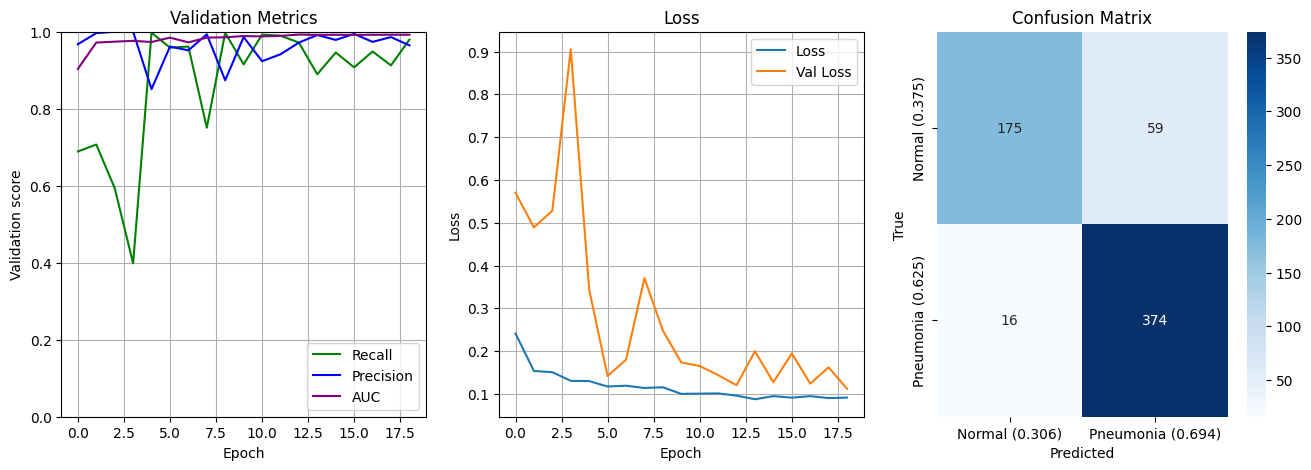


========== training member: cnn_b ==========
Epoch 1/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.5044 - auc: 0.6436 - loss: 0.3537 - precision: 0.8308 - recall: 0.4172 - tn: 1019.0000 - tp: 1620.0000 - val_accuracy: 0.7691 - val_auc: 0.8559 - val_loss: 0.6094 - val_precision: 0.9214 - val_recall: 0.7532 - val_tn: 110.0000 - val_tp: 293.0000 - learning_rate: 0.0010
Epoch 2/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.7288 - auc: 0.8259 - loss: 0.2671 - precision: 0.9056 - recall: 0.7084 - tn: 956.0000 - tp: 2475.0000 - val_accuracy: 0.7958 - val_auc: 0.9208 - val_loss: 0.4593 - val_precision: 0.9796 - val_recall: 0.7404 - val_tn: 129.0000 - val_tp: 288.0000 - learning_rate: 0.0010
Epoch 3/25
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.8195 - auc: 0.9061 - loss: 0.2005 - precision: 0.9369 - recall: 0.8114 - tn: 1023.0000 - tp: 2835.0000 - val_accuracy: 0.6489 - val_auc: 0.9365 - val_loss: 0.7548 - val_precision: 0.9952 - val_recall: 0.5296 - val_

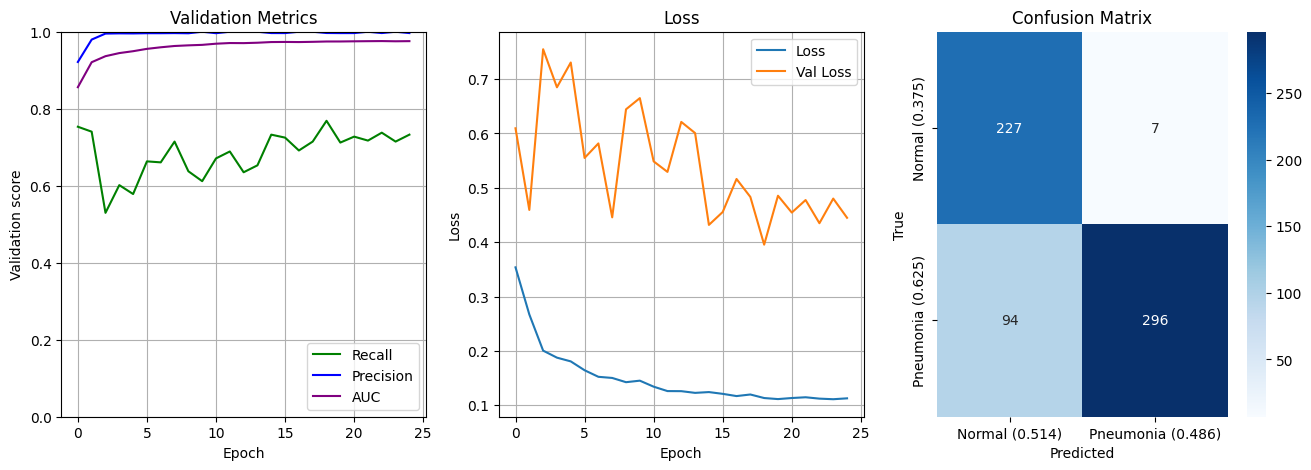


saved members: ['/content/drive/MyDrive/cv-checkpoints/best_cnn_a.keras', '/content/drive/MyDrive/cv-checkpoints/best_cnn_b.keras']


In [8]:
member_paths = []
for label, builder in MEMBERS:
    member_paths.append(train_member(label, builder))
print("\nsaved members:", member_paths)

## Ensemble and test-time augmentation

Two robustness tricks, stacked: averaging the members' probabilities, and averaging each
member over a few lightly augmented copies of every image at inference. Because the val/test
loaders are ordered, the passes line up and can be averaged element-wise.

In [9]:
# mild, label-preserving augmentation for TTA (no flip, since anatomy is left/right specific)
tta_aug = tf.keras.Sequential(
    [
        tf.keras.layers.RandomRotation(0.05),
        tf.keras.layers.RandomTranslation(0.05, 0.05),
        tf.keras.layers.RandomZoom(0.05),
    ],
    name="tta_aug",
)


def predict_proba_tta(model, ds, n_aug=4):
    # average a clean pass with n_aug augmented passes (order preserved)
    passes = [model.predict(ds, verbose=0).ravel()]
    for _ in range(n_aug):
        aug_ds = ds.map(lambda x, y: (tta_aug(x, training=True), y))
        passes.append(model.predict(aug_ds, verbose=0).ravel())
    return np.mean(passes, axis=0)


def ensemble_proba(paths, ds, n_aug=4):
    # mean TTA probability across all ensemble members
    member_probs = []
    for p in paths:
        reset_keras()
        model = tf.keras.models.load_model(p)
        member_probs.append(predict_proba_tta(model, ds, n_aug=n_aug))
    return np.mean(member_probs, axis=0), member_probs


val_proba, val_member_probs = ensemble_proba(member_paths, validation_ds)
test_proba, test_member_probs = ensemble_proba(member_paths, test_ds)

print("Per-member vs ensemble ROC-AUC (test):")
for path, probs in zip(member_paths, test_member_probs):
    print(f"  {os.path.basename(path):<18} {roc_auc_score(y_test, probs):.4f}")
print(f"  {'ENSEMBLE + TTA':<18} {roc_auc_score(y_test, test_proba):.4f}")

Per-member vs ensemble ROC-AUC (test):
  best_cnn_a.keras   0.9608
  best_cnn_b.keras   0.9585
  ENSEMBLE + TTA     0.9615


## Probability calibration

A model can rank cases well (high AUC) yet output over-confident probabilities. Temperature
scaling fits one scalar that divides the logits, chosen to minimize validation cross-entropy.
It cannot change the ranking, so AUC is unchanged; it only rescales confidence.

Fitted temperature: 0.514  (T>1 means the model was over-confident)


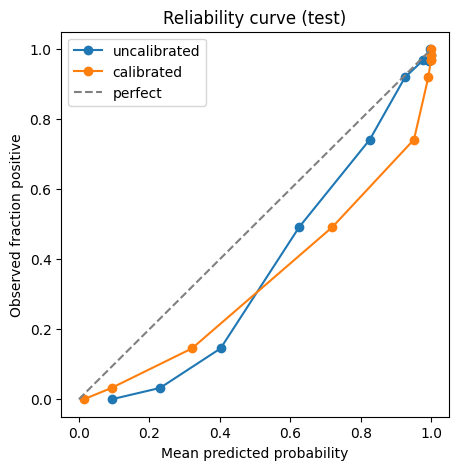

In [10]:
def _to_logit(p, eps=1e-6):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))


val_logits = _to_logit(val_proba)


def _nll(T):
    p = 1.0 / (1.0 + np.exp(-val_logits / T))
    p = np.clip(p, 1e-7, 1 - 1e-7)
    return -np.mean(y_val * np.log(p) + (1 - y_val) * np.log(1 - p))


temperature = float(minimize_scalar(_nll, bounds=(0.05, 10.0), method="bounded").x)
print(
    f"Fitted temperature: {temperature:.3f}  (T>1 means the model was over-confident)"
)


def calibrate(p):
    return 1.0 / (1.0 + np.exp(-_to_logit(p) / temperature))


test_proba_cal = calibrate(test_proba)

fig, ax = plt.subplots(figsize=(5, 5))
for probs, name in [(test_proba, "uncalibrated"), (test_proba_cal, "calibrated")]:
    frac_pos, mean_pred = calibration_curve(
        y_test, probs, n_bins=10, strategy="quantile"
    )
    ax.plot(mean_pred, frac_pos, marker="o", label=name)
ax.plot([0, 1], [0, 1], "--", color="gray", label="perfect")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed fraction positive")
ax.set_title("Reliability curve (test)")
ax.legend(loc="upper left")
plt.show()

## Operating point: balanced vs clinical

A single AUC says the model ranks cases well, but the confusion matrix depends on the
threshold. We report two, both chosen on validation: a balanced point (Youden's J), which
treats a missed normal and a missed pneumonia as equally costly, and a clinical point, the
highest threshold that still hits a target sensitivity of 0.95.

Balanced threshold: 0.730  (Youden's J)
Clinical threshold: 0.641  (target sensitivity >= 0.95)

Test-set performance (ensemble + TTA, calibrated probabilities):
default 0.5                acc=0.891  sensitivity=0.977  specificity=0.748  precision=0.866  false negatives=9
balanced 0.730             acc=0.901  sensitivity=0.941  specificity=0.833  precision=0.904  false negatives=23
clinical 0.641             acc=0.897  sensitivity=0.956  specificity=0.799  precision=0.888  false negatives=17

Test ROC-AUC: 0.9615


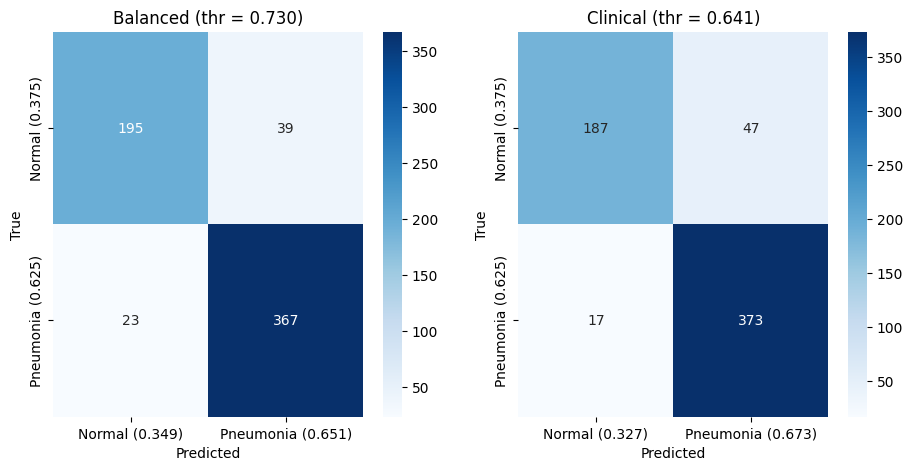

In [11]:
TARGET_SENSITIVITY = 0.95

val_proba_cal = calibrate(val_proba)

# clinical point: the highest threshold that still hits the sensitivity target
prec, rec, thr = precision_recall_curve(y_val, val_proba_cal)
ok = rec[:-1] >= TARGET_SENSITIVITY
if ok.any():
    clinical_threshold = float(thr[ok].max())
else:
    clinical_threshold = float(thr[np.argmax(rec[:-1])])
    print("WARNING: target sensitivity unreachable on val; using max-recall threshold")

# balanced point: Youden's J (max sensitivity + specificity - 1)
fpr_v, tpr_v, thr_v = roc_curve(y_val, val_proba_cal)
balanced_threshold = float(thr_v[np.argmax(tpr_v - fpr_v)])

print(f"Balanced threshold: {balanced_threshold:.3f}  (Youden's J)")
print(
    f"Clinical threshold: {clinical_threshold:.3f}  (target sensitivity >= {TARGET_SENSITIVITY})\n"
)


def report(name, proba, thr_):
    pred = (proba >= thr_).astype("int32")
    tp = int(((pred == 1) & (y_test == 1)).sum())
    tn = int(((pred == 0) & (y_test == 0)).sum())
    fp = int(((pred == 1) & (y_test == 0)).sum())
    fn = int(((pred == 0) & (y_test == 1)).sum())
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    prec_ = tp / (tp + fp) if (tp + fp) else float("nan")
    acc = (tp + tn) / len(y_test)
    print(
        f"{name:<26} acc={acc:.3f}  sensitivity={sens:.3f}  specificity={spec:.3f}  "
        f"precision={prec_:.3f}  false negatives={fn}"
    )


print("Test-set performance (ensemble + TTA, calibrated probabilities):")
report("default 0.5", test_proba_cal, 0.5)
report(f"balanced {balanced_threshold:.3f}", test_proba_cal, balanced_threshold)
report(f"clinical {clinical_threshold:.3f}", test_proba_cal, clinical_threshold)
print(f"\nTest ROC-AUC: {roc_auc_score(y_test, test_proba_cal):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
show_confusion_matrix(
    y_test,
    (test_proba_cal >= balanced_threshold).astype("int32"),
    ax=axes[0],
    title=f"Balanced (thr = {balanced_threshold:.3f})",
)
show_confusion_matrix(
    y_test,
    (test_proba_cal >= clinical_threshold).astype("int32"),
    ax=axes[1],
    title=f"Clinical (thr = {clinical_threshold:.3f})",
)
plt.show()

## Grad-CAM: where is the model looking?

Grad-CAM on the first ensemble member, for its most confident pneumonia case. At 28x28 the
localization is coarse, but a healthy model should still favor the lung region over the
borders.

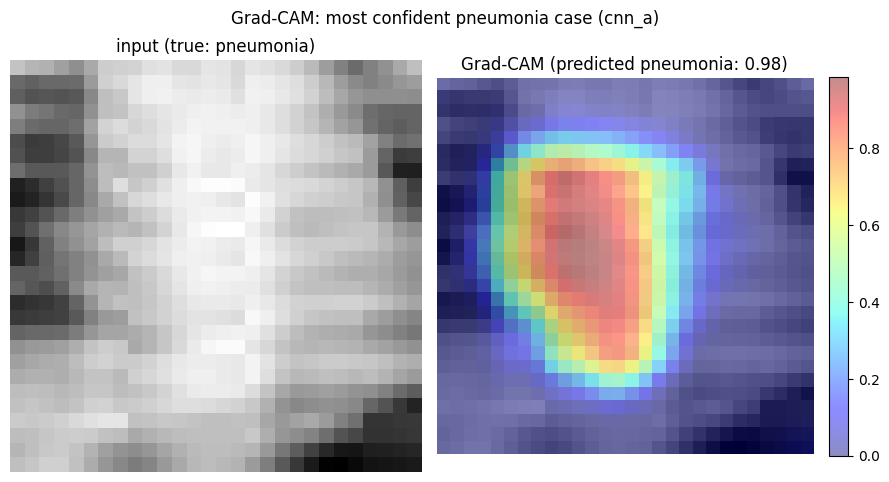

np.float32(0.9814552)

In [12]:
# Grad-CAM on the first ensemble member, for its most confident PNEUMONIA case.
member_model = tf.keras.models.load_model(member_paths[0])

scores = np.asarray(test_member_probs[0])
pos_i = max((i for i in range(len(y_test)) if y_test[i] == 1), key=lambda i: scores[i])
all_images = np.concatenate([bx.numpy() for bx, _ in test_ds], axis=0)

show_gradcam(
    all_images[pos_i],
    member_model,
    class_name="pneumonia",
    true_label="pneumonia",
    title=f"Grad-CAM: most confident pneumonia case ({member_model.name})",
)

In [13]:
notebook_end_time = datetime.datetime.now()
print(
    f"Notebook last run (end-to-end): {notebook_end_time} "
    f"(duration: {notebook_end_time - notebook_start_time})"
)

Notebook last run (end-to-end): 2026-07-13 11:24:55.845410 (duration: 0:08:55.263226)
